# Project Overview

The main purpose of this project is to explore whether neural networks can learn to compress images better than classical codecs like JPEG and zlib.

Classical codecs use mathematical rules like frequency decomposition or pattern matching to compress things. A Variational Autoencoder (VAE) however, would learn the structure of a specific type of data from examples, and then use that to compress data more efficiently.

The core question is thus: on structured, domain-specific data, can a learned compressor beat a general purpose one?

In [1]:
import sys
import os
sys.path.insert(0, os.path.dirname(os.getcwd()))

import torch
import matplotlib.pyplot as plt
import numpy as np

from training.dataloader import get_dataloaders, get_input_dim, DATASET_INFO

## So, why MNIST?

There are three reasons for this.

1. It's fast. Each image is 28x28 pixels and grayscale, so training is pretty fast. We can iterate quickly: try something, see if it works, and adjust.
2. It's well understood. If the reconstructions look wrong, we'll know the problem is in the model, not in the data.
3. It's structured. This is the main reason honestly. All the images are digits on a plain background, and this kind of regularity is exactly what we want.

Maybe we'll move to more varied and complicated datasets like CIFAR-10 to see how the comparison against classical codecs changes, but that's for later.

In [2]:
train_loader, test_loader = get_dataloaders(dataset='mnist', data_dir='../data', batch_size=128)
images, labels = next(iter(train_loader))

print("Batch shape: ", images.shape)
print("Label shape: ", labels.shape)
print("Pixels min/max: ", images.min().item(), "to", images.max().item())
print("Pixels mean: ", images.mean().item())
print("Pixel std: ", images.std().item())

Batch shape:  torch.Size([128, 1, 28, 28])
Label shape:  torch.Size([128])
Pixels min/max:  0.0 to 1.0
Pixels mean:  0.13333669304847717
Pixel std:  0.3114199638366699


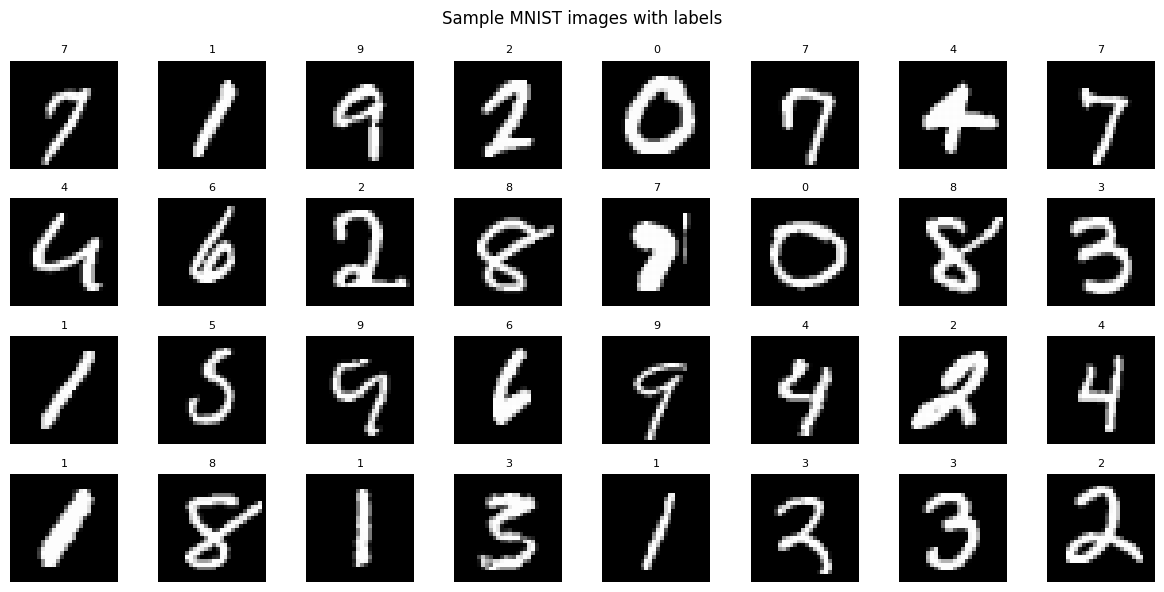

In [3]:
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(32):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(str(labels[i].item()), fontsize=8)
    axes[i].axis('off')

plt.suptitle('Sample MNIST images with labels')
plt.tight_layout()
plt.show()

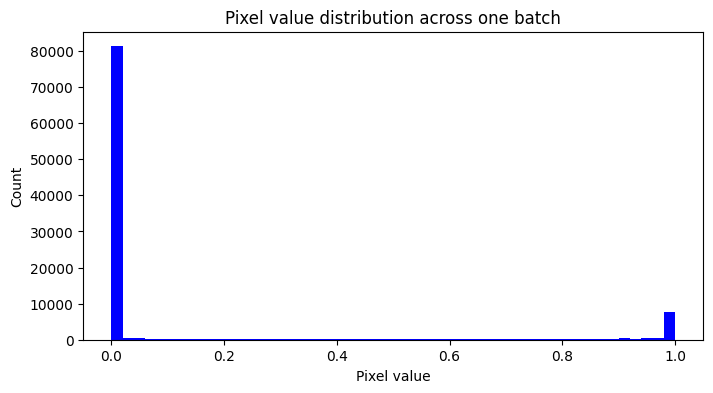

In [4]:
plt.figure(figsize=(8, 4))
plt.hist(images.numpy().flatten(), bins=50, color='blue', edgecolor='none')
plt.xlabel('Pixel value')
plt.ylabel('Count')
plt.title('Pixel value distribution across one batch')
plt.show()

Shape: sample.shape
Non-zero pixels:  115 out of 784


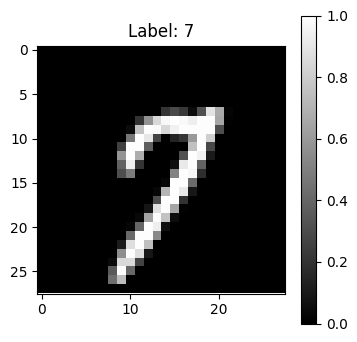

In [5]:
sample = images[0].squeeze()

print("Shape: sample.shape")
print("Non-zero pixels: ", (sample>0).sum().item(), "out of", sample.numel())

plt.figure(figsize=(4, 4))
plt.imshow(sample, cmap='gray')
plt.colorbar()
plt.title(f"Label: {labels[0].item()}")
plt.show()

## CIFAR-10

Moving to a harder dataset. CIFAR-10 has 60,000 color images across 10 classes 
(planes, cars, birds, cats, deer, dogs, frogs, horses, ships, trucks).

Main differences from MNIST:
- 3 channels (RGB) instead of 1 (grayscale)
- 32x32 pixels instead of 28x28
- Much more varied content, stuff is no longer just centered digits on plain background
- Input dimension is 3 * 32 * 32 = 3072 vs 784 for MNIST

This variety is what makes CIFAR-10 harder to compress. A VAE trained on MNIST 
exploits the fact that all images share the same basic structure. CIFAR-10 has 
far less regularity, which is where classical codecs like JPEG start to compete more effectively.

In [6]:
train_loader, test_loader = get_dataloaders(dataset='cifar10', data_dir='../data', batch_size=128)

images, labels = next(iter(test_loader))
print("Batch shape:", images.shape)
print("Pixel range:", images.min().item(), "to", images.max().item())
print("Pixel mean:", images.mean().item())
print("Pixel std:", images.std().item())

Batch shape: torch.Size([128, 3, 32, 32])
Pixel range: 0.0 to 1.0
Pixel mean: 0.4683331549167633
Pixel std: 0.2558227777481079


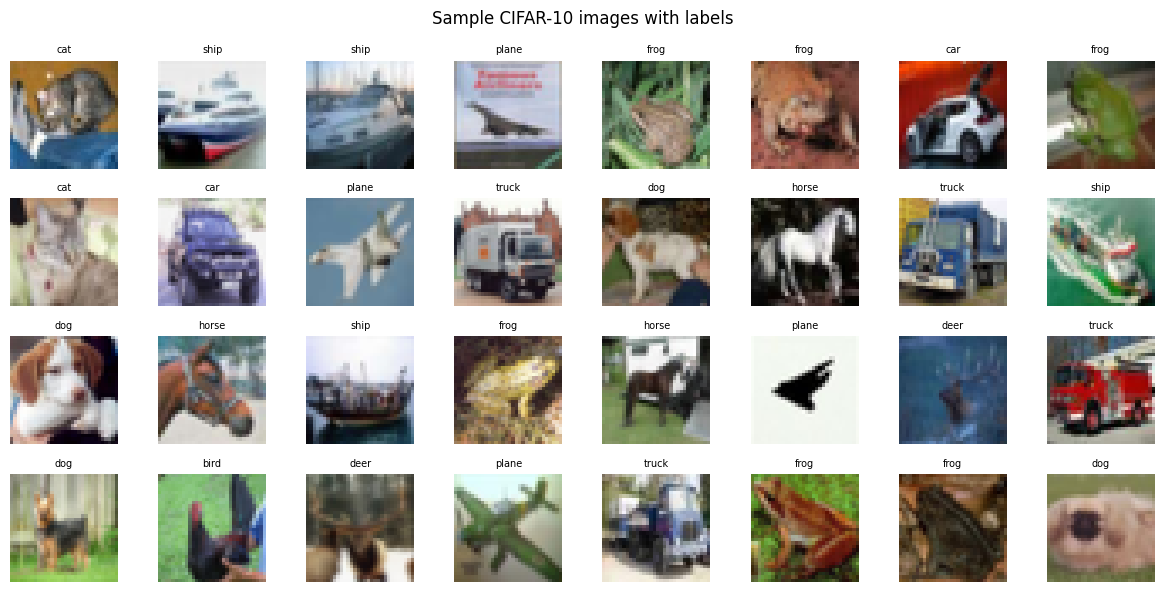

In [7]:
classes = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']

fig, axes = plt.subplots(4, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(32):
    img = images[i].permute(1, 2, 0) 
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i].item()], fontsize=7)
    axes[i].axis('off')

plt.suptitle('Sample CIFAR-10 images with labels')
plt.tight_layout()
plt.show()

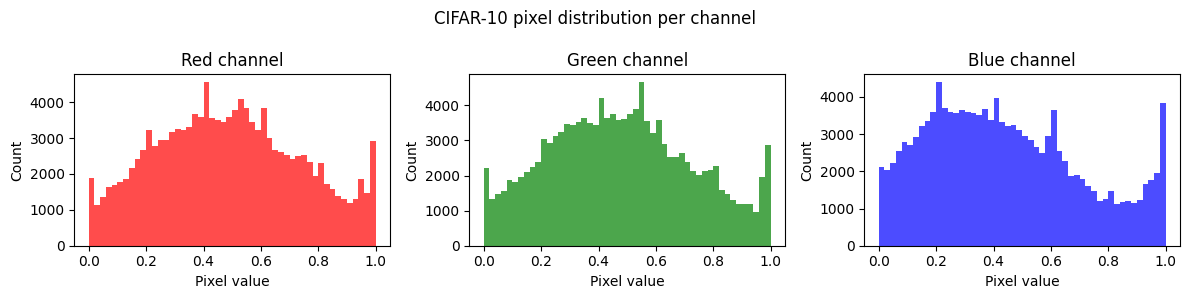

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channel_names = ['Red', 'Green', 'Blue']

for c in range(3):
    axes[c].hist(images[:, c, :, :].numpy().flatten(), 
                 bins=50, color=['red', 'green', 'blue'][c], alpha=0.7)
    axes[c].set_title(f'{channel_names[c]} channel')
    axes[c].set_xlabel('Pixel value')
    axes[c].set_ylabel('Count')

plt.suptitle('CIFAR-10 pixel distribution per channel')
plt.tight_layout()
plt.show()

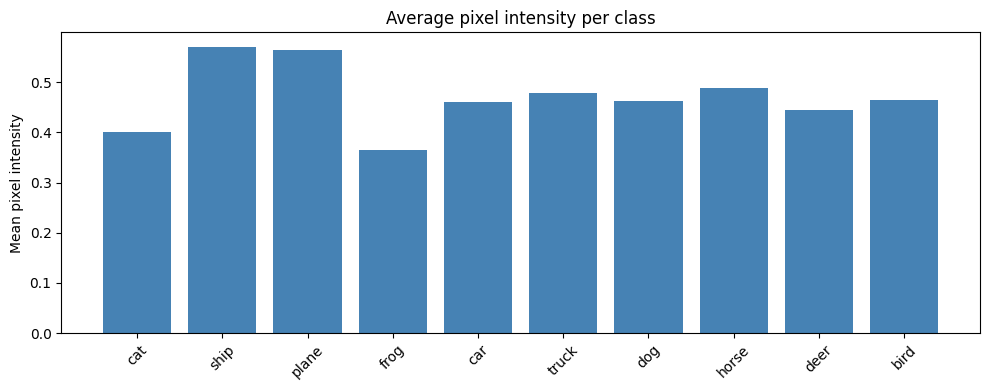

In [9]:
class_means = {}
for img, label in zip(images, labels):
    cls = classes[label.item()]
    if cls not in class_means:
        class_means[cls] = []
    class_means[cls].append(img.mean().item())

class_avg = {k: sum(v)/len(v) for k, v in class_means.items()}

plt.figure(figsize=(10, 4))
plt.bar(class_avg.keys(), class_avg.values(), color='steelblue')
plt.ylabel('Mean pixel intensity')
plt.title('Average pixel intensity per class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## CelebA

CelebA contains 200,000+ celebrity face images, all center-cropped and aligned.
We resize to 64×64 here for training.

This is our domain-specific dataset. Unlike MNIST and CIFAR-10, every image shares the same underlying structure with two eyes, nose, mouth, roughly oval face shape. This consistency is exactly what's going to make this amazing for VAE. The model doesn't need to learn a broad distribution, it learns one very specific structure and gets very good at it.

What I'm hoping for here is this: at high compression ratios, a face-trained VAE will produce recognisable faces while JPEG at the same file size produces blocking artifacts.
Input dimension: 3 × 64 × 64 = 12,288.

In [10]:
celeba_train_loader, celeba_test_loader = get_dataloaders(dataset='celeba', data_dir='../data', batch_size=128)

celeba_images, _ = next(iter(celeba_test_loader))
print("Batch shape:", celeba_images.shape)
print("Pixel range:", celeba_images.min().item(), "to", celeba_images.max().item())
print("Pixel mean:", celeba_images.mean().item())
print("Pixel std:", celeba_images.std().item())
print("Total test images:", len(celeba_test_loader.dataset))

Batch shape: torch.Size([128, 3, 64, 64])
Pixel range: 0.0 to 1.0
Pixel mean: 0.41287961602211
Pixel std: 0.2907199561595917
Total test images: 19962


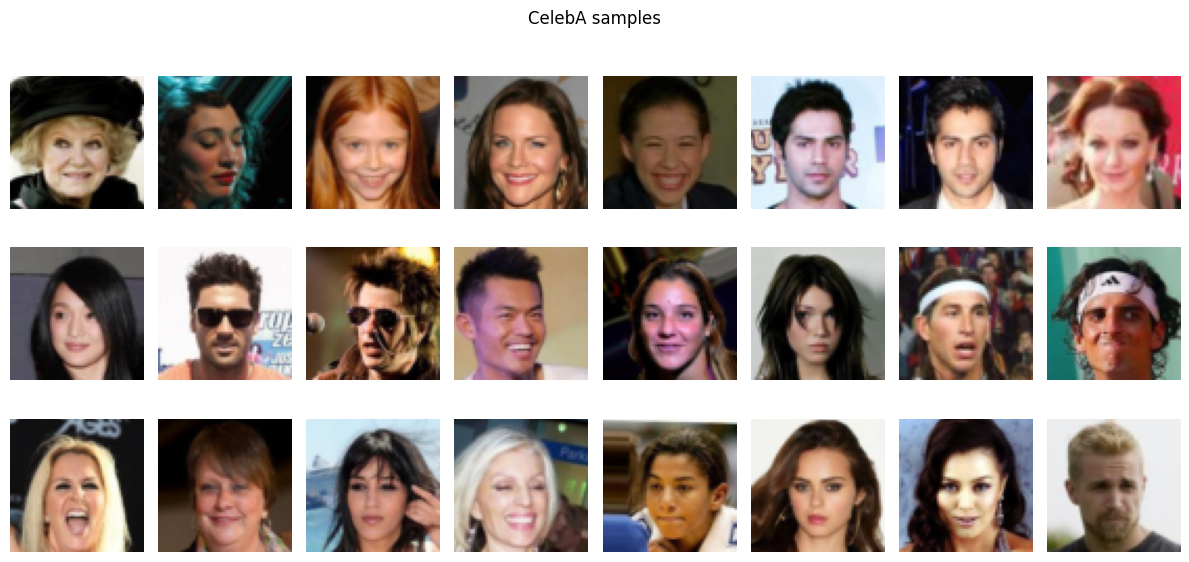

In [11]:
fig, axes = plt.subplots(3, 8, figsize=(12, 6))
axes = axes.flatten()

for i in range(24):
    axes[i].imshow(celeba_images[i].permute(1, 2, 0))
    axes[i].axis('off')

plt.suptitle('CelebA samples')
plt.tight_layout()
plt.show()

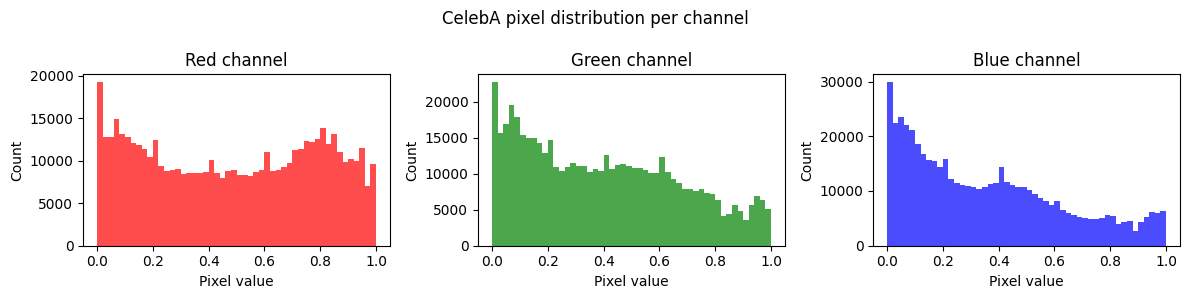

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
channel_names = ['Red', 'Green', 'Blue']
colors = ['red', 'green', 'blue']

for c in range(3):
    axes[c].hist(
        celeba_images[:, c, :, :].numpy().flatten(),
        bins=50, color=colors[c], alpha=0.7
    )
    axes[c].set_title(f'{channel_names[c]} channel')
    axes[c].set_xlabel('Pixel value')
    axes[c].set_ylabel('Count')

plt.suptitle('CelebA pixel distribution per channel')
plt.tight_layout()
plt.show()

## Dataset Comparison Summary

| Property | MNIST | CIFAR-10 | CelebA |
|----------|-------|----------|--------|
| Images | 70,000 | 60,000 | 200,000+ |
| Resolution | 28×28 | 32×32 | 64×64 (resized) |
| Channels | 1 | 3 | 3 |
| Input dim | 784 | 3,072 | 12,288 |
| Content | Digits | 10 varied classes | Aligned faces |
| Structure | High | Low | Very high |

Structure here means how consistent the layout is across images. High structure means a VAE has more to exploit. This is why we expect our models to perform 
best on CelebA at high compression ratios, and worst on CIFAR-10.

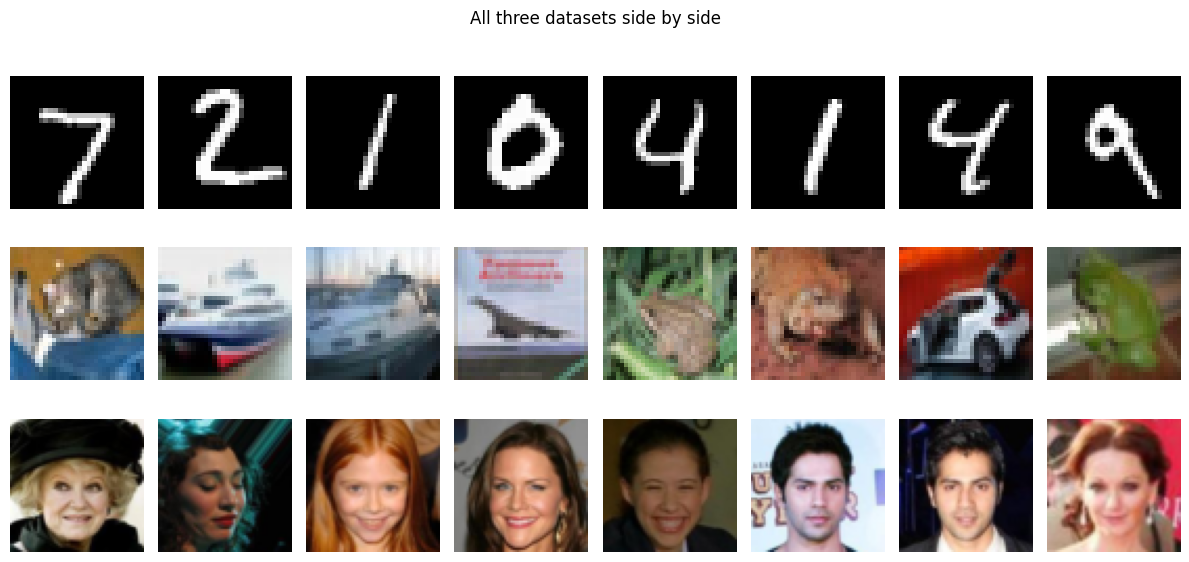

In [14]:
fig, axes = plt.subplots(3, 8, figsize=(12, 6))

mnist_images, _ = next(iter(get_dataloaders(dataset='mnist', data_dir='../data')[1]))
cifar_imgs, _ = next(iter(test_loader))
celeba_imgs, _ = next(iter(celeba_test_loader))

for i in range(8):
    axes[0, i].imshow(mnist_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    axes[1, i].imshow(cifar_imgs[i].permute(1, 2, 0))
    axes[1, i].axis('off')

    axes[2, i].imshow(celeba_imgs[i].permute(1, 2, 0))
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('MNIST', fontsize=9)
axes[1, 0].set_ylabel('CIFAR-10', fontsize=9)
axes[2, 0].set_ylabel('CelebA', fontsize=9)

plt.suptitle('All three datasets side by side')
plt.tight_layout()
plt.show()

## Observations

**Pixel distributions:**
- MNIST is heavily binary with most pixels being zero (background) with a spike near one 
(digit strokes). Very little in between.
- CIFAR-10 follows a rough normal distribution 
centered around 0.4 for each RGB channel, which seems normal for such a wide variety of natural images.
- CelebA shows a different pattern per channel: red is relatively flat, while green and blue slope downward, reflecting the warm skin tone bias across face images.

**Which dataset will the VAE compress best?**

CelebA will show the most meaningful compression advantage over JPEG. Faces have consistent structure which the VAE will (hopefully) learn to exploit. At high compression ratios, the VAE maintains recognisable face structure while JPEG produces blocking artifacts. MNIST is easy for everyone including JPEG, so the comparison there is less interesting. CIFAR-10 is where classical codecs will compete most effectively because the content is too varied for the VAE to exploit reliably.

**What CelebA's consistency tells us:**

Domain-specific compression works because the model only needs to learn one 
manifold in image space. Every face image lives in roughly the same region with the
same layout and same proportions. The VAE's latent space doesn't need to represent 
anything except faces, so it can allocate all of its capacity to capturing 
face-specific variation like expression, hair, and lighting.

**Input dimension growth:**

Larger input dimensions dramatically increase model complexity when using linear 
layers: the first layer alone goes from 200k parameters on MNIST to 3 million 
on CelebA. More parameters means more data needed, more epochs, and higher risk 
of overfitting. This is one of the core motivations for moving to convolutional 
architectures since convolutions share parameters across spatial positions so the 
parameter count doesn't explode with resolution.